In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import root
from scipy.integrate import solve_ivp                      # для решения ОДУ
from scipy.integrate import cumulative_trapezoid           # для координаты капли 

In [2]:
atm = 101325

# I. Распад капель 

## 1. Исходные данные по форсунке

In [3]:
# Параметры воды
rho_w  = 998.0
mu_w   =  1004e-6
cp_l = 4180.0               # теплоемкость воды, Дж/(кг·К)
h_fg = 2.45e6               # теплота испарения, Дж/кг
sigma  = 72e-3              # коэффцииен поверхностного натяжения, N/m

In [4]:
# Данные о форсунке

Исходная форсунка (общий вод)

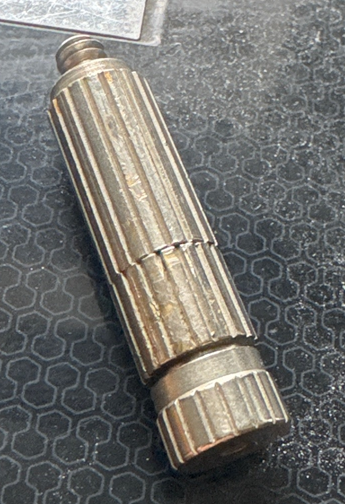

In [5]:
dc = 0.1e-3       # диаметр выходного сечения, м (на ней так написано)

Скорее всего это спецификация для нее - https://www.naturalfog.com/NFN-type-12-24unc2A.html

In [6]:
# Тогда дополнительные параметры
theta = 45         # угол раскрытия струи, m
dmin = 5.90e-6     # минимальный размер капель, m
dmax = 25.20e-6    # максимальный размер капель, m
dm   = 11.00e-6    # majority size, m

Расходную характеристику можно попробовать взять здесь https://www.naturalfog.com/blog-01.html

In [7]:
Gw  = np.array([0.018, 0.021, 0.022, 0.024, 0.026, 0.028, 0.029])*0.001/60*rho_w     # расход форсунки, кг/c
dP = np.array([400, 500, 600, 700, 800, 900, 1000])*6895                             # перепад давления, Pa

Интерполируем данные

In [8]:
def Gw4dP(dp):
    return np.interp(dp, dP, Gw)

In [9]:
dp = np.linspace(25e5, 100e5)
G = Gw4dP(dp)

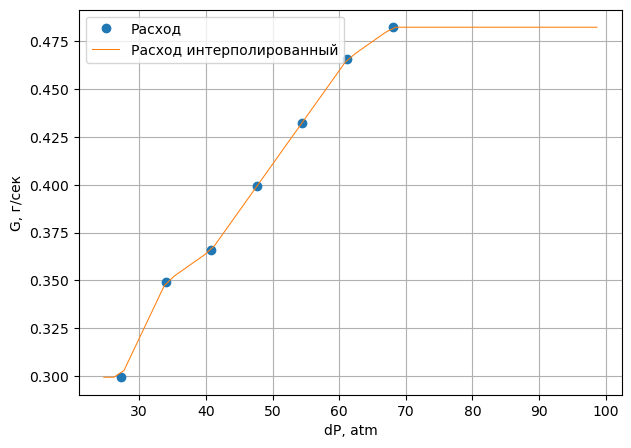

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plt.plot(dP/atm, Gw*1000,'o', label='Расход')
plt.plot(dp/atm, G*1000, '-', lw=0.75, label= 'Расход интерполированный')
plt.xlabel('dP, atm')
plt.ylabel('G, г/сек')
plt.legend()
plt.grid()
plt.show()

## 2. Распределение капель по диаметру

Для построения распределения Rosin--Rammler принимаем интегральную функцию распределения в виде

$$
F(d)=1-\exp\left[-\left(\frac{d}{X}\right)^q\right]
$$

где:

- $F(d)$ — накопленная доля капель с диаметром меньше $d$
- $d$ — диаметр капли, м
- $X$ — характерный размер распределения, м
- $q$ — параметр ширины распределения Rosin--Rammler

Плотность распределения по диаметру получается дифференцированием:

$$
f(d)=\frac{q}{X}\left(\frac{d}{X}\right)^{q-1}\exp\left[-\left(\frac{d}{X}\right)^q\right]
$$

Имеем следущие табличные значения:

- диаметр отверстия форсунки: $d_0 = 0.10$ мм
- расход при $1000$ psi: $G = 0.029$ л/мин
- минимальный характерный диаметр капель: $d_{\min} = 5.9$ мкм
- максимальный характерный диаметр капель: $d_{\max} = 25.2$ мкм
- наиболее характерный размер капель: $d_m = 11.0$ мкм


Далее принимается:

$$
q = 3.63
$$

Значение `majority = 11.0 mu` интерпретируется как модальный диаметр распределения:

$$
d_m = 11.0\ \mu m
$$

Для распределения Розина--Рамблера мода определяется выражением

$$
d_m = X\left(\frac{q-1}{q}\right)^{1/q}
$$

Отсюда параметр масштаба равен

$$
X = \frac{d_m}{\left(\frac{q-1}{q}\right)^{1/q}}
$$


In [11]:
# параметр q
qtab = 3.63

In [12]:
def getRRdist(d, Xd, q):
    F = 1 - np.exp(-(d/Xd)**q)
    return F

In [13]:
Xtab = dm*(1-1/qtab)**(-1./qtab)
print(f'Оптимальное значение параметра X = {Xtab*1e6:0.2f}')

Оптимальное значение параметра X = 12.02


Определим диаметры dmin и dmax соответствующие вероятностям
- $F(d_1)=0.01$
- $F(d_2)=0.99$

Для определения диаметра капли, соответствующего заданной доле $p$, по известным параметрам функции Rosin-Rammler:

$$
F(d_p)=p
$$

Тогда:

$$
p = 1-\exp\left[-\left(\frac{d_p}{X}\right)^q\right]
$$

$$
\exp\left[-\left(\frac{d_p}{X}\right)^q\right]=1-p
$$

$$
\left(\frac{d_p}{X}\right)^q=-\ln(1-p)
$$

Отсюда диаметр, соответствующий квантилю $p$, определяется как

$$
d_p = X\left[-\ln(1-p)\right]^{1/q}
$$


In [14]:
def per2d(p, X, q):
    return X * (-np.log(1 - p))**(1 / q)

In [15]:
dmin_tab = per2d(0.01, Xtab, qtab)
dmax_tab = per2d(0.99, Xtab, qtab)
print(f'Dmin = {dmin_tab * 1e6:0.2f} um')
print(f'Dmax = {dmax_tab * 1e6:0.2f} um')

Dmin = 3.39 um
Dmax = 18.31 um


Определим Диаметра D32 по полученному распределению



Он используется для характеристики распределения капель или частиц по размерам и определяется как отношение третьего момента распределения ко второму моменту:

$$
D_{32}=\frac{\int d^3 n(d)\,dd}{\int d^2 n(d)\,dd}
$$

где:

- $d$ — диаметр капли или частицы;
- $n(d)$ — плотность распределения частиц по диаметрам;
- $\int d^3 n(d)\,dd$ — величина, пропорциональная суммарному объёму частиц;
- $\int d^2 n(d)\,dd$ — величина, пропорциональная суммарной площади поведеления в этом интервале.деления в этом интервале.

In [16]:
def dist2d32(X, q, dmax, dmin):
    d = np.linspace(dmin, dmax, 10000)
    f = getRRdist(d, X, q)
    num = np.trapz(d**3 * np.gradient(f, d), d)
    den = np.trapz(d**2 * np.gradient(f, d), d)
    return num / den

In [17]:
d32_tab = dist2d32(Xtab, qtab, dmax_tab, dmin_tab)
print(f'Значение D32 по табличному распределению  = {d32_tab*1e6:0.2f}')

Значение D32 по табличному распределению  = 12.50


In [18]:
# Для распределения капель воды по диаметрам
d_tab = np.linspace(dmin_tab, dmax_tab, 10000)
dist_tab = getRRdist(d_tab, Xtab, qtab)
dist_dens_tab = np.gradient(dist_tab, d_tab)

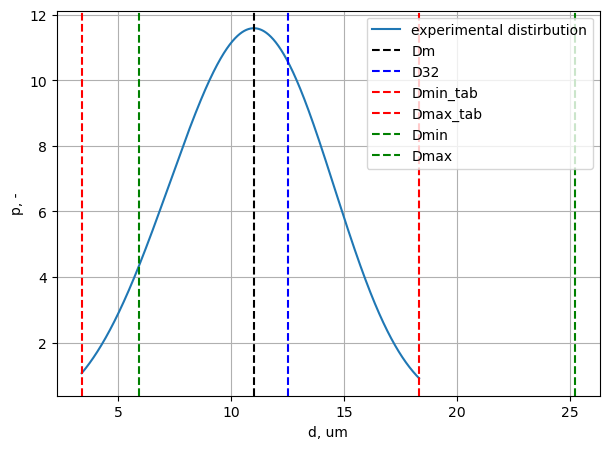

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plt.plot(d_tab*1e6, dist_dens_tab/10000, label ='experimental distirbution')
plt.axvline(dm*1e6, linestyle="--", color='black', label='Dm')
plt.axvline(d32_tab*1e6, linestyle="--", color='blue', label='D32')
plt.axvline(dmin_tab*1e6, linestyle="--", color='red', label='Dmin_tab')
plt.axvline(dmax_tab*1e6, linestyle="--", color='red', label='Dmax_tab')
plt.axvline(dmin*1e6, linestyle="--", color='green', label='Dmin')
plt.axvline(dmax*1e6, linestyle="--", color='green', label='Dmax')
plt.legend()
plt.grid()
plt.xlabel('d, um')
plt.ylabel('p, -')
plt.show()

По тем неизвестным данным, что у нас есть нормально восстановить распределение капель по диаметру не получится. Использовать стандартное значение q и подобрать X по dm мне показалось лучшим вариантом. Зеленые границы это данные производителя по минимальным и максимальным диаметрам капель. У меня немного уехало, потому что я считал по dm, а в Розине-Рамблере только два параметра, и q и dm достаточно. Если брать границы dmin и dmах уплывет средний диаметр капли и станет 17 где то.

### Droplets breakup - Эмпирика по определению D32

Форсунка относится к типу pressure-swirl / simplex, то есть к центробежной напорной форсунке, которая формирует полую коническую струю. На выходе формируется пленка, а не сразу капли. Чтобы посчитать толщину пленки можно использовать книжку (формула 5.54) "Atomization and Sprays" By Arthur H. Lefebvre, Vincent G. McDonell

$$
t = 3.66 \left[d_c \frac{FN\,\mu_L}{\left(\Delta P_L\,\rho_L\right)^{1/2}}\right]^{0.25}
$$

где $d_c$ — диаметр выходного отверстия, $FN$ — flow number, $\mu_L$ — вязкость жидкости, $\rho_L$ — плотность жидкости, $\Delta P_L$ — перепад давления.

Заутеровский диаметр капли для форсунки
$$
D_{32} = 4.52 \left( \frac{\sigma \mu_L^2}{\rho_A \Delta P_L^2} \right)^{0.25} (t \cos \theta)^{0.25}
\;+\;
0.39 \left( \frac{\sigma \rho_L}{\rho_A \Delta P_L} \right)^{0.25} (t \cos \theta)^{0.75}
$$

где:

- $D_{32}$ — средний диаметр капель по Заутеру (Sauter Mean Diameter, SMD), м
- $\sigma$ — поверхностное натяжение жидкости, Н/м
- $\mu_L$ — динамическая вязкость жидкости, кг/(м·с)
- $\rho_A$ — плотность окружающего газа, кг/м$^3$
- $\Delta P_L$ — перепад давления на форсунке, Па
- $t$ — толщина жидкой плёнки на выходе из форсунки, м
- $\theta$ — полуугол факела распыла
- $\rho_L$ — плотность жидкости, кг/м$^3$

In [20]:
def th(G, dp, rho_a):
    FN = G/np.sqrt(dp*rho_w)
    f = mu_w*dc*FN/np.sqrt(dp*rho_w)
    th = 3.66*f**0.25
    p1 = (sigma/rho_a*(mu_w/dp)**2)**0.25
    p2 = (sigma*rho_w/rho_a/dp)**0.25
    ct = np.cos(np.deg2rad(theta/2))
    SMD = 4.52 * p1 * (th * ct)**0.25 + 0.39 * p2 * (th * ct)**0.75
    return th, SMD

Тест для максимального расхода для сравнения с табличными данными

In [21]:
Gwc  = Gw[-1]           # максимальный расход              0.029 LPM
dPt   = dP[-1]          # максимальный перепад давления    1000  PSI
rho_a = 1.18            # плотность воздуха атмосфера
thickness, d32_imp = th(Gwc, dPt, rho_a)
print(f't = {thickness*1e6:0.2f} um')
print(f'D32 = {d32_imp * 1e6:0.2f} um')

t = 33.52 um
D32 = 10.85 um


Сопоставление расчётного диаметра Заутера и диаметра Заутера, восстановленного из аппроксимирующего распределения, показывает наличие расхождения.

По корреляционной формуле для режима производителя получено:

$$
D_{32,\text{calc}} = 10.85\ \mu m
$$

При восстановлении распределения капель по диаметру с использованием функции Розина--Рамблера и параметров, выбранных из данных производителя, для этого же режима получено:

$$
D_{32,\text{RR}} = 12.50\ \mu m
$$


In [22]:
# Расхождение значений
print(f'Расхождение значений D32 {(d32_tab-d32_imp)/d32_imp*100:0.1f} %')

Расхождение значений D32 15.2 %


В дальнейшем функция для расчета $D_{32}$ используется не для прямого задания абсолютного масштаба распределения Розина--Рамблера, а для определения относительного изменения характерного диаметра между режимами.

Параметр масштаба распределения пересчитывается по соотношению

$$
X_{\text{new}} = X_{\text{ref}}
\frac{D_{32,\text{calc,new}}}{D_{32,\text{calc,ref}}}
$$

где:
- $X_{\text{ref}}$ — параметр распределения для базового режима, восстановленный по данным производителя,
- $D_{32,\text{calc,ref}}$ — расчетный диаметр Заутера для базового режима,
- $D_{32,\text{calc,new}}$ — расчетный диаметр Заутера для нового режима.

При таком подходе сохраняется форма распределения, задаваемая параметром $q$, а весь спектр капель масштабируется пропорционально изменению расчетного диаметра Заутера. Следовательно, расчетный $D_{32}$ используется как масштабный параметр, определяющий относительное сжатие или растяжение распределения при переходе от одного режима к другому.

То есть используем максимально табличные данные производителя и "натягиваем" на различные режимы впрыскивания по расчету.

## 3. Наша форсунка (капли)

### Заутеровский диаметр

У нас есть расходная характеристика, используем ее для получения расходов по перепаду давления в наших условиях

In [23]:
# Параметры в форкамере
P0 = 530e3         # давление заторможенного потока, Pa
R = 289
T0 = 295           # температура заторможенного потока, K
rho_air = P0/R/T0  # плотность
k_air   = 0.0255   # теплопроводность воздуха Вт/(м·К)
cp_air  = 1005     # теплоемкость воздуха, Дж/(кг·К)
mu = 0.69e-2/(T0+122)*(T0/273)**(3/2)   # вязкость
Pinj = 55e5        # примем, что у нас такое давление подачи, Pa

In [24]:
# Расход через форсунку
Gtube = Gw4dP(Pinj-P0)
print(f'Расход воды = {Gtube*1e3:0.2f} г/с')

Расход воды = 0.41 г/с


In [25]:
# Параметры распада на капели
thickness, d32 = th(Gtube, Pinj-P0, rho_air)
print(f't = {thickness*1e6:0.2f} um')
print(f'D32 = {d32 * 1e6:0.2f} um')

t = 34.85 um
D32 = 8.10 um


Вообще странно, что с увеличение плотность диаметр капель снижается......... ИИ посоветывал проверить число Вебера, которое определяет распад капель в потоке

**Число Вебера**

In [26]:
# Пуская впрыскиваем в стоячий объем, это все равно для сравнения чисел Вебера, не важно что у нас есть какая-то скорость потока  
G4w = np.array([Gwc, Gtube])
rho4w = np.array([rho_a, rho_air])
Uw = G4w / rho_w / (np.pi * dc**2 / 4)
print(f'Скорость подачи воды в объем по данным производителя {Uw[0]:0.02f}')
print(f'Скорость подачи воды в объем для нашего случая {Uw[1]:0.02f}')
We_a  = Uw**2*dc*rho4w/sigma
print(f'Число Вебера аэродинамическое по данным производителя {We_a[0]:0.02f}')
print(f'Число Вебера аэродинамическое для нашего случая {We_a[1]:0.02f}')

Скорость подачи воды в объем по данным производителя 61.54
Скорость подачи воды в объем для нашего случая 51.81
Число Вебера аэродинамическое по данным производителя 6.21
Число Вебера аэродинамическое для нашего случая 23.18


То есть лучше "разрывается" пленка в первую очередь из-за более высокой плотности воздуха

### Распределение капель по диаметру

Для нашего расчетного режима получаем:

In [27]:
# Заутеровский диаметр капли d32
_, d32_tab = th(Gwc, dPt, rho_a)             # для табличных данных
_, d32_exp = th(Gtube, Pinj-P0, rho_air)     # для эксперимента
print(f'D32 = {d32_exp * 1e6:0.2f} um')

D32 = 8.10 um


In [28]:
Xexp = Xtab*d32_exp/d32_tab
print(f'X = {Xexp * 1e6:0.2f} um')

X = 8.97 um


In [29]:
dmin_exp = per2d(0.01, Xexp, qtab)
dmax_exp = per2d(0.99, Xexp, qtab)
print(f'Dmin = {dmin_exp * 1e6:0.2f} um')
print(f'Dmax = {dmax_exp * 1e6:0.2f} um')

Dmin = 2.53 um
Dmax = 13.67 um


In [30]:
d32_exp_dist = dist2d32(Xexp, qtab, dmax_exp, dmin_exp)
print(f'Значение D32 по табличному распределению  = {d32_exp_dist*1e6:0.2f}')

Значение D32 по табличному распределению  = 9.33


In [31]:
# Для распределения капель воды по диаметрам
d_exp = np.linspace(dmin_exp, dmax_exp, 10000)
dist_exp = getRRdist(d_exp, Xexp, qtab)
dist_dens_exp = np.gradient(dist_exp, d_exp)

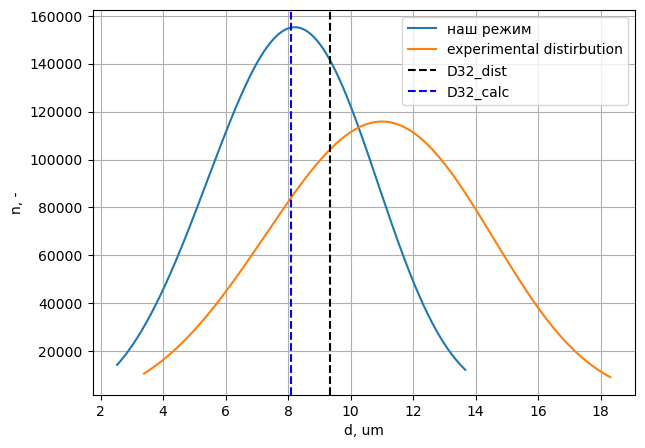

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plt.plot(d_exp*1e6, dist_dens_exp, label ='наш режим')
plt.plot(d_tab*1e6, dist_dens_tab, label ='experimental distirbution')
plt.axvline(d32_exp_dist*1e6, linestyle="--", color='black', label='D32_dist')
plt.axvline(d32_exp*1e6, linestyle="--", color='blue', label='D32_calc')
plt.legend()
plt.grid()
plt.xlabel('d, um')
plt.ylabel('n, -')
plt.show()

Распределение стало уже, потому что у нас уменьшился диаметр капель, а на нем было как раз все завязано. Насколько это физично вопрос конечно 

# II Испарение капель в трубе

## 1.Испарение отдельной капели

In [33]:
Ug = 15            # скорость потока перед хонейкомбом, m/s
G = 5              # расход, kg/s
rh0 = 0            # воздух сухой

### Дополнительные свойства, пара и воды

In [34]:
# нам нужен коэффициент диффузии воды в воздух, можно наверное эту формулу использовать где есть зависимость от давления и температуры
# https://portal.tpu.ru/SHARED/b/BVBORISOV/academic/heat-mass-exchange/Tab/TP_Lecture_12.pdf страница 5
def Dv (T, p):
  p = p/1e5     # в барах
  d0 = 2.28e-5
  n = 1.8
  return d0/p*(T/273)**n

In [35]:
# считаем, что коэффициент диффузии паров воды зависит от параметров окружащей среды, тогда:
Dvg = Dv (T0, P0)
print(f'Dv_g = {Dvg * 1e5:0.2f}*1e5 m2/s')         # в 4 раза меньше, чем при атмосфере

Dv_g = 0.49*1e5 m2/s


In [36]:
# Давление насыщенного водяного пара, Па. Приближенная формула Magnus/Tetens, хороша для диапазона ~0...100 °C. врет на 100 градусах
def p_sat(T):
  T = T-273
  psat = 610.94 * np.exp(17.625 * T / (T + 243.04))
  return psat

In [37]:
# Массовая доля водяного пара в смеси воздух-пар.
def vapor_mass_fraction(p_vp, p0):
    M_vp = 18e-3
    M_air = 29e-3
    return (M_vp * p_vp) / (M_vp * p_vp + M_air * (p0 - p_vp))

In [38]:
# пересчет влажности
def RH2W(RH, T, p_total):
    p_v = RH * p_sat(T)
    return 0.62198 * p_v / (p_total - p_v)

def W2RH(W, T, p_total):
    p_v = p_total * W / (0.62198 + W)
    return p_v / p_sat(T)

Считаем, что с каплями ничего не происходит дальше, они не распадаются, а просто испаряются в объеме форкамеры. Начальная температура капель пускай будет отличаться от температуры среды. Скорость тоже. Обмен импульсом будет односторонний, то есть капля будет приобретать скорость среды, но среда ускорятся не будет. Будет несколько характерных период - релаксации скорости, релаксации температуры и движения капли в потоке с его скоростью и температурой

У нас будет таким образом, три ОДУ:

### Уравнение движения капли

Скорость капли изменяется под действием аэродинамического сопротивления:

$$
m_d \frac{dU_d}{dt}
=
\frac{1}{2} C_D \rho_g A_d (U_g-U_d)\lvert U_g-U_d \rvert
$$

где:
- $m_d$ — масса капли, кг
- $U_d$ — скорость капли, м/с
- $U_g$ — скорость газа, м/с
- $C_D$ — коэффициент сопротивления
- $\rho_g$ — плотность газа, кг/м$^3$
- $A_d$ — лобовая площадь капли, м$^2$

Для сферической капли:

$$
m_d = \frac{\pi}{6}\rho_l D^3
$$

$$
A_d = \frac{\pi}{4}D^2
$$

где:
- $\rho_l$ — плотность жидкости, кг/м$^3$
- $D$ — диаметр капли, м

Коэффициент сопротивления можно вычислять как:

$$Cd = \frac {24} {Re} + \frac 4 {\sqrt(Re)} + 0.4 $$

где число Рейнольдса капли равно

$$
Re = \frac{\rho_g \lvert U_g-U_d \rvert D}{\mu_g}
$$

а $\mu_g$ — динамическая вязкость газа, кг/(м·с).

---


In [39]:
def dudt(Dt, U):
    slip = abs(Ug - U)
    if abs(slip) < 1e-10:
        return 0.0
    Red =  abs(Ug - U)*Dt*rho_air/mu
    Cd  = 24/Red + 4/np.sqrt(Red) + 0.4
    md  = rho_w*np.pi/6*Dt**3
    Ad  = np.pi/4*Dt**2
    rhs =  0.5*(rho_air*Ad)/md*abs(Ug - U)*(Ug - U)*Cd
    return rhs

### Уравнение теплового баланса капли

Температура капли изменяется за счёт конвективного теплообмена с газом и затрат теплоты на испарение:

$$
m_d c_{p,l}\frac{dT_d}{dt}
=
\alpha_w A_s (T_g-T_d) - \dot m_{evap} h_{fg}
$$

где:
- $c_{p,l}$ — теплоёмкость жидкости, Дж/(кг·К)
- $T_d$ — температура капли, K или °C
- $T_g$ — температура газа, K или °C
- $\alpha_w$ — коэффициент теплоотдачи, Вт/(м$^2$·К)
- $A_s$ — площадь поверхности капли, м$^2$
- $\dot m_{evap}$ — скорость испарения капли, кг/с
- $h_{fg}$ — теплота парообразования, Дж/кг

Для сферической капли:

$$
A_s = \pi D^2
$$

Коэффициент теплоотдачи выражается через число Нуссельта:

$$
\alpha_w = \frac{Nu\,k_g}{D}
$$

где:
- $k_g$ — теплопроводность газа, Вт/(м·К)

Для одиночной капли можно использовать корреляцию Ranz--Marshall:

$$
Nu = 2 + 0.6\,Re^{1/2}Pr^{1/3}
$$

$$
Pr = \frac{\mu_g c_{p,g}}{k_g}
$$

где $c_{p,g}$ — теплоёмкость газа, Дж/(кг·К).

---

In [40]:
def dTdt(Dt, mevap, U, T):
  md  = rho_w*np.pi/6*Dt**3
  Red = abs(Ug - U)*Dt*rho_air/mu
  As  = np.pi*Dt**2
  Pr  = mu*cp_air/k_air
  Nu = 2 + 0.6 *Red**0.5*Pr**(1./3)
  alpha_w = Nu*k_air/Dt
  p1 = alpha_w*As*(Tg - T)
  p2 = - mevap*h_fg
  rhs = (p1 + p2)/md/cp_l
  return rhs

### Уравнение изменения массы капли (перепишим, относительно диаметра капли, будем считать, что она сферическая) Раздел 3.2.1 — “Maxwell and Stefan–Fuchs Models”  у Сажина

Масса капли уменьшается вследствие испарения:

$$
\frac{dm_d}{dt} = -\dot m_{evap}
$$

Скорость испарения можно записать через число Шервуда и число Сполдинга по массообмену:

$$
\dot m_{evap}
=
\pi D \rho_g D_{v,g} Sh \ln(1+B_M)
$$

где:
- $D_{v,g}$ — коэффициент диффузии пара в газе, м$^2$/с
- $Sh$ — число Шервуда
- $B_M$ — число Сполдинга по массообмену

Число Шервуда для одиночной капли:

$$
Sh = 2 + 0.6\,Re^{1/2}Sc^{1/3}
$$

$$
Sc = \frac{\mu_g}{\rho_g D_{v,g}}
$$

Число Сполдинга по массообмену:

$$
B_M = \frac{Y_{v,s}-Y_{v,\infty}}{1-Y_{v,s}}
$$

где:
- $Y_{v,s}$ — массовая доля пара на поверхности капли
- $Y_{v,\infty}$ — массовая доля пара в основном потоке

---



In [41]:
def dmdt(Dt, hr, U, T):
  Red = abs(Ug - U)*Dt*rho_air/mu
  Sc =  mu/rho_air/Dvg
  Sh = 2 + 0.6 *Red**0.5*Sc**(1./3)
  psat_w = p_sat(T)                                   # давление насыщения у поверхности капли
  psat_air = p_sat(Tg)                                # давление насыщения в основном потоке
  Yv_s    = vapor_mass_fraction(psat_w, P0)
  Yv_inf  = vapor_mass_fraction(hr*psat_air, P0)
  Bm = (Yv_s -Yv_inf)/(1-Yv_s)
  mevap = np.pi*Dt*rho_air*Dvg*Sh*np.log1p(Bm)
  rhs = -2* mevap/np.pi/rho_w/Dt**2                   # перейдем к решение по диаметру
  return rhs, mevap

## 2. Расчет испарения

In [42]:
# Газовая среда и начальные условия
Ug = Ug          # скорость газа, м/с
Tg = T0          # температура газа, K
pg = P0          # давление газа, Pa
RH_inf = rh0     # относительная влажность вдали от капли, 0...1
tfin = 25        # время расчета

D_min_stop = 1e-7  # считаем каплю испарившейся при D = 0.1 мкm

In [43]:
# у нас непонятно какая скорость на выходе из форсунки,
# но есть посчитанная толщина пленки, и расход попробуем через него пересчитать,
# и сравним если просто разделить на проходное сечение форсунки - но берем все таки расходную - разница не велика, мороки и пояснений меньше
Unoz = Gtube / rho_w / (np.pi * dc**2 / 4)
print(f'Скорость пленки и капель на выходе из форсунки  = {Unoz:0.2f} м/с')

Скорость пленки и капель на выходе из форсунки  = 51.81 м/с


In [44]:
# начальные параметры для расчета
D0 = d32_exp_dist            # начальный диаметр капли, м
Udrop0 = -Unoz                # начальная скорость капли, м/с
Tdrop0 = 273+25              # начальная температура капли, K

### Правая часть системы ОДУ для одиночной капли

Функция `single_droplet_rhs(t, y)` задаёт правые части системы обыкновенных дифференциальных уравнений, описывающей эволюцию **одной капли** в воздушном потоке.

Вектор неизвестных записан в виде

$$
y = [D,\ U,\ T]
$$


где:
- $D_t$ — текущий диаметр капли
- $U_t$ — текущая скорость капли
- $T_t$ — текущая температура капли

В начале функции диаметр ограничивается снизу:

$$
D_t = \max(D_t,\ D_{\min})
$$

Это делается для того, чтобы избежать численных проблем при стремлении диаметра к нулю.


In [45]:
def single_droplet_rhs(t, y):
    """
    y = [Dt, Ut, Tt]
    """
    Dt, Ut, Tt = y
    Dt = max(Dt, D_min_stop)
    # 1. Движение капли
    rhs4u = dudt(Dt, Ut)
    # 2. Изменение диаметра
    hr= RH_inf                                                 # тестируем так с нулевой начальной влажность, все равно одна капля не повлияет
    rhs4Dt, m2evap = dmdt(Dt, hr, Ut, Tt)
    # 3. Теплообмен
    rhs4T = dTdt(Dt, m2evap, Ut, Tt)

    return [rhs4Dt, rhs4u, rhs4T]

In [46]:
# добавил момент когда фиксации когда капля испарится
def event_evaporated(t, y):
    return y[0] - D_min_stop                                                             

In [47]:
event_evaporated.terminal = True
event_evaporated.direction = -1

In [48]:
y0 = [D0, Udrop0, Tdrop0]

sol = solve_ivp(
    single_droplet_rhs,
    t_span=(0.0, tfin),
    y0=y0,
    method="RK45",
    events=event_evaporated,
    rtol=1e-7,
    atol=[1e-11, 1e-5, 1e-5],
    max_step=1e-4,
)

## 3.Результаты расчеты

In [49]:
# распакуем результаты расчета в переменные
t = sol.t
D = sol.y[0]
U = sol.y[1]
Td = sol.y[2]
x = cumulative_trapezoid(U, t, initial=0.0)

print(f"success = {sol.success}")
print(f"t_final = {t[-1]:.6f} s")
print(f"D_final = {D[-1] * 1e6:.4f} um")
print(f"U_final = {U[-1]:.3f} m/s")
print(f"T_final = {Td[-1]:.2f} K")
print(f"x_final = {x[-1]:.3f} m")

if len(sol.t_events[0]) > 0:
    print(f"Капля испарилась за {sol.t_events[0][0]:.6f} s")

success = True
t_final = 0.166711 s
D_final = 0.1000 um
U_final = 15.000 m/s
T_final = 288.79 K
x_final = 2.496 m
Капля испарилась за 0.166711 s


In [50]:
# Скорость испарения
mdot_evap = np.zeros_like(t)
for i in range(len(t)):
    Dt = D[i]
    Ut = U[i]
    Tt = Td[i]
    _, mdot_evap[i] = dmdt(Dt, RH_inf, Ut, Tt)

# Перевод единиц
t_ms = t * 1e3
D_um = D * 1e6
T_C = Td - 273.15
mdot_ng_s = mdot_evap * 1e12  # кг/с -> нг/с

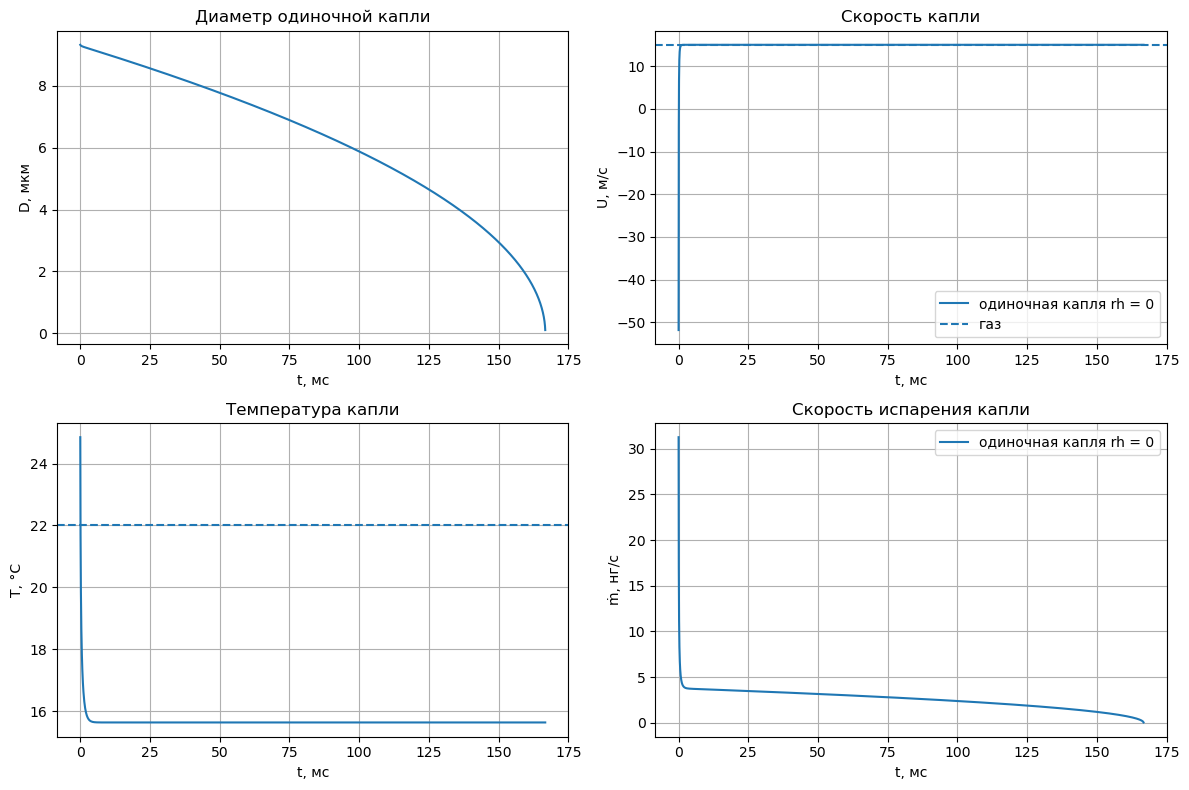

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Диаметр капли
ax[0, 0].plot(t_ms, D_um, label='одиночная капля rh = 0')
ax[0, 0].set_xlabel('t, мс')
ax[0, 0].set_ylabel('D, мкм')
ax[0, 0].set_title('Диаметр одиночной капли')
ax[0, 0].grid(True)

# 2. Скорость капли
ax[0, 1].plot(t_ms, U, label='одиночная капля rh = 0')
ax[0, 1].axhline(Ug, linestyle='--', label='газ')
ax[0, 1].set_xlabel('t, мс')
ax[0, 1].set_ylabel('U, м/с')
ax[0, 1].set_title('Скорость капли')
ax[0, 1].legend()
ax[0, 1].grid(True)

# 3. Температура капли
ax[1, 0].plot(t_ms, T_C, label='одиночная капля rh = 0')
ax[1, 0].axhline(Tg-273, linestyle='--', label='температура газа')
ax[1, 0].set_xlabel('t, мс')
ax[1, 0].set_ylabel('T, °C')
ax[1, 0].set_title('Температура капли')
ax[1, 0].grid(True)

# 4. Скорость испарения
ax[1, 1].plot(t_ms, mdot_ng_s, label='одиночная капля rh = 0')
ax[1, 1].set_xlabel('t, мс')
ax[1, 1].set_ylabel('ṁ, нг/с')
ax[1, 1].set_title('Скорость испарения капли')
ax[1, 1].grid(True)

plt.tight_layout()
plt.legend()
plt.show()

В сухом потоке воздуха, капля испаряется за 2.5 метра при движении по трубе от места впрыскивания. Если менять направление впрыскивания (делать против скорости потока) то процесс выравнения скорости все равно очень быстрый и это практически не на что не влияет - хотя, испарение зависит от разности скорости и лучше впрыскивать против потока. Если говорить об большом количестве капель наверное у них какой то начальный импульс должен этот процесс делать подольше, но в таком виде модель этого не ловит.  **Вообще задавая распределение капель по диаметру я могу попробовать в Fluent посчитать, с учетом реальной геометрии трубы, например до ханейкомба.**

# III Испарение ансамбля капель в трубе и влажность потока

Тут как бы две дополнительные сложности:
 - нужно бить на группы капли по распределению Розина - Рамблера, чтобы считать капли в этих группах одинаковыми по размеру и испарять их;
 - с испарением капель будет меняться влажность и значит будет еще одно уравнение в системе.

In [52]:
# Начальные условия, влажность
W0  = RH2W(rh0, T0, P0)
RH0 = W2RH(W0, T0, P0)
print(f"W0 = {W0:.2f} kg_vapor/kg_dry_air")
print(f"RH0 = {RH0:.2f}")

W0 = 0.00 kg_vapor/kg_dry_air
RH0 = 0.00


### 1. Капли одного диаметра

Количества капель, впрыскиваемых в секунду

Масса одной сферической капли диаметра $D_{32}$ определяется как

$$
m_{\text{drop},0} = \rho_w \frac{\pi}{6} D_{32}^{3}
$$

где:

- $m_{\text{drop},0}$ — масса одной капли, кг;
- $\rho_w$ — плотность воды, кг/м³;
- $D_{32}$ — средний диаметр капли по Заутеру, м.

Количество капель, впрыскиваемых в секунду, определяется из массового расхода жидкости:

$$
\dot{N}_{\text{drop}} =
\frac{|G_{\text{tube}}|}{m_{\text{drop},0}}
$$

где:

- $\dot{N}_{\text{drop}}$ — количество капель, впрыскиваемых в секунду, 1/с;
- $G_{\text{tube}}$ — массовый расход воды через форсунку, кг/с.

In [53]:
m_drop0 = rho_w * np.pi / 6 * D0**3
Ndrop_dot = int(Gtube / m_drop0)
print(f"Количество капель диаметра D32, впрыскиваемых в секунду = {Ndrop_dot} 1/s")

Количество капель диаметра D32, впрыскиваемых в секунду = 956888502 1/s


Дополнительно уравнение для влажности воздуха

$$
\frac{dW}{dt} =
\frac{\dot{N}_{\text{drop}} \dot{m}_{\text{evap}}}{G}
$$

где:

- $W$ — абсолютная влажность воздуха, кг/кг;
- $\dot{N}_{\text{drop}}$ — количество капель, впрыскиваемых в секунду, 1/с;
- $\dot{m}_{\text{evap}}$ — скорость испарения одной капли, кг/с;
- $G$ — массовый расход воздуха, кг/с.

Это уравнение показывает, что влажность воздуха увеличивается за счёт испарения всех капель, находящихся в потоке. Чем больше скорость испарения одной капли и чем больше количество капель, тем быстрее растёт влагосодержание воздуха.

In [54]:
def single_droplet_rhs_humidity(t, y):
    """
    y = [Dt, Ut, Tt, Wt]
    """
    Dt, Ut, Tt, Wt = y
    Dt = max(Dt, D_min_stop)
    
    # 1. Движение капли
    rhs4u = dudt(Dt, Ut)
    # 2. Изменение диаметра
    rh_t =  W2RH(Wt, Tg, P0)                                             
    rhs4Dt, m2evap = dmdt(Dt, rh_t, Ut, Tt)
    # 3. Теплообмен
    rhs4T = dTdt(Dt, m2evap, Ut, Tt)
    # 4. Рост влажности воздуха
    rhs4W = Ndrop_dot * m2evap / G

    return [rhs4Dt, rhs4u, rhs4T, rhs4W]

In [55]:
y0 = [D0, Udrop0, Tdrop0, W0]

sol = solve_ivp(
    single_droplet_rhs_humidity,
    t_span=(0.0, tfin),
    y0=y0,
    method="RK45",
    events=event_evaporated,
    rtol=1e-7,
    atol=[1e-11, 1e-5, 1e-5, 1e-8],
    max_step=1e-4,
)

In [56]:
# распакуем результаты расчета в переменные
t_sing = sol.t
D_sing = sol.y[0]
U_sing = sol.y[1]
Td_sing = sol.y[2]
W_sing = sol.y[3]
RH_sing = W2RH(W_sing, T0, P0)
x_sing = cumulative_trapezoid(U_sing, t_sing, initial=0.0)

print(f"success = {sol.success}")
print(f"t_final = {t_sing[-1]:.6f} s")
print(f"D_final = {D_sing[-1] * 1e6:.4f} um")
print(f"U_final = {U_sing[-1]:.3f} m/s")
print(f"T_final = {Td_sing[-1]:.2f} K")
print(f"RH_final = {RH_sing[-1]:.5f}")
print(f"x_final = {x_sing[-1]:.3f} m")

if len(sol.t_events[0]) > 0:
    print(f"Капля испарилась за {sol.t_events[0][0]:.6f} s")

success = True
t_final = 0.169553 s
D_final = 0.1000 um
U_final = 15.000 m/s
T_final = 288.96 K
RH_final = 0.02623
x_final = 2.539 m
Капля испарилась за 0.169553 s


In [57]:
# Скорость испарения и относительная влажность
mdot_evap_sing = np.zeros_like(t_sing)
for i in range(len(t_sing)):
    Dt_sing = D_sing[i]
    Ut_sing = U_sing[i]
    Tt_sing = Td_sing[i]
    RHt_sing  = RH_sing[i]
    _, mdot_evap_sing[i] = dmdt(Dt_sing, RHt_sing, Ut_sing, Tt_sing)

# Перевод единиц
t_ms_sing = t_sing * 1e3
D_um_sing = D_sing * 1e6
T_C_sing = Td_sing - 273.15
mdot_ng_s_sing = mdot_evap_sing * 1e12  # кг/с -> нг/с

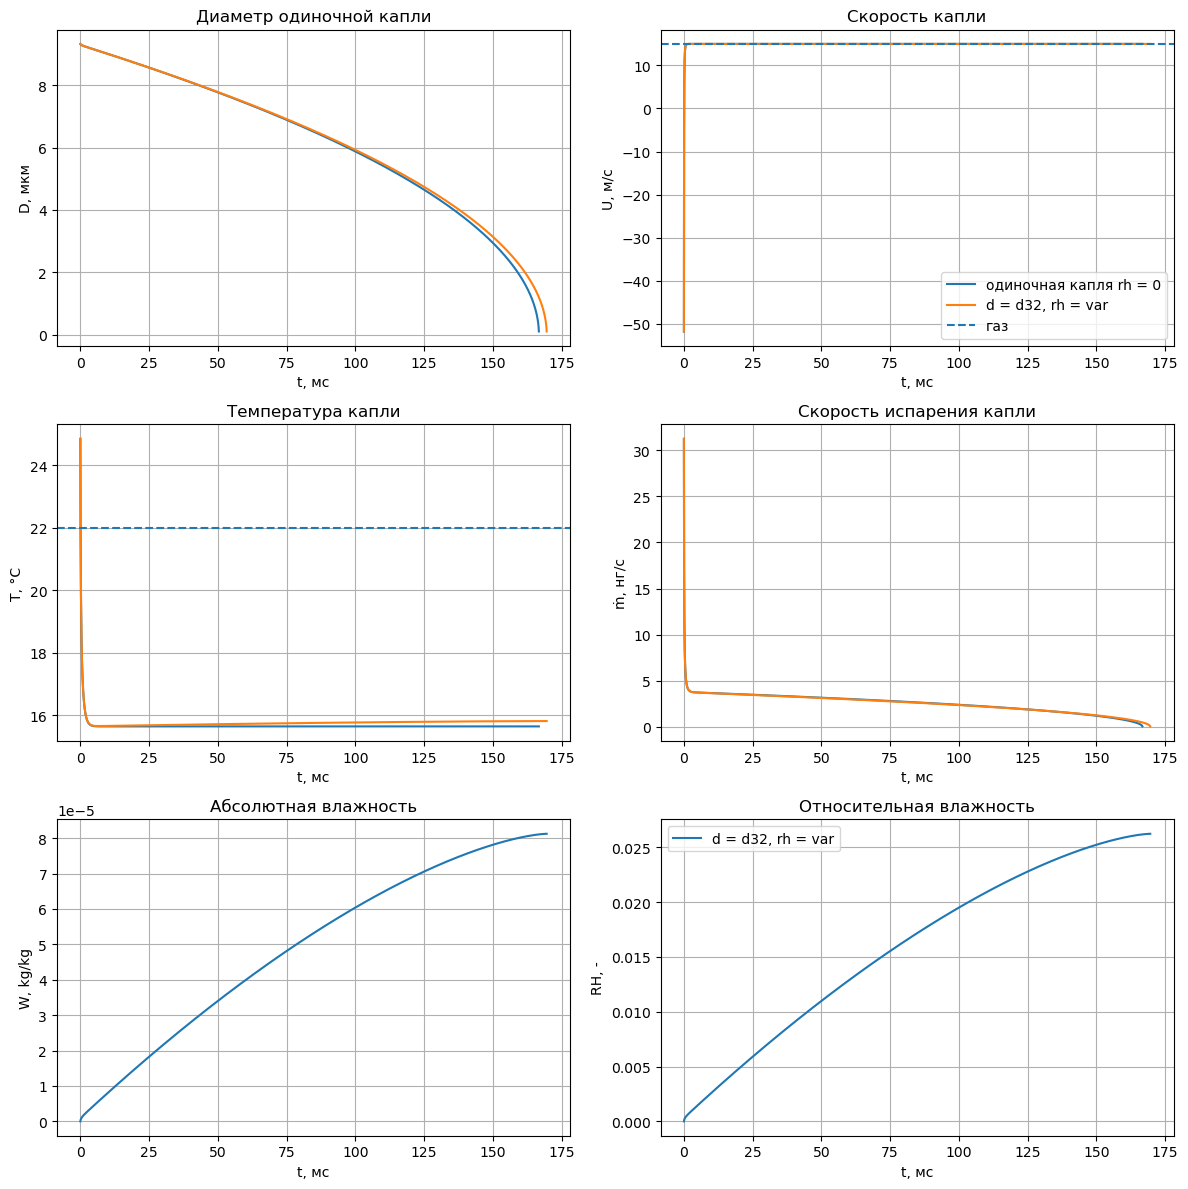

In [58]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

# 1. Диаметр капли
ax[0, 0].plot(t_ms, D_um, label='одиночная капля rh = 0')
ax[0, 0].plot(t_ms_sing, D_um_sing, label='d = d32, rh = var')
ax[0, 0].set_xlabel('t, мс')
ax[0, 0].set_ylabel('D, мкм')
ax[0, 0].set_title('Диаметр одиночной капли')
ax[0, 0].grid(True)

# 2. Скорость капли
ax[0, 1].plot(t_ms, U, label='одиночная капля rh = 0')
ax[0, 1].plot(t_ms_sing, U_sing, label='d = d32, rh = var')
ax[0, 1].axhline(Ug, linestyle='--', label='газ')
ax[0, 1].set_xlabel('t, мс')
ax[0, 1].set_ylabel('U, м/с')
ax[0, 1].set_title('Скорость капли')
ax[0, 1].legend()
ax[0, 1].grid(True)

# 3. Температура капли
ax[1, 0].plot(t_ms, T_C, label='одиночная капля rh = 0')
ax[1, 0].plot(t_ms_sing, T_C_sing, label='d = d32, rh = var')
ax[1, 0].axhline(Tg-273, linestyle='--', label='температура газа')
ax[1, 0].set_xlabel('t, мс')
ax[1, 0].set_ylabel('T, °C')
ax[1, 0].set_title('Температура капли')
ax[1, 0].grid(True)

# 4. Скорость испарения
ax[1, 1].plot(t_ms, mdot_ng_s, label='одиночная капля rh = 0')
ax[1, 1].plot(t_ms_sing, mdot_ng_s_sing, label='d = d32, rh = var')
ax[1, 1].set_xlabel('t, мс')
ax[1, 1].set_ylabel('ṁ, нг/с')
ax[1, 1].set_title('Скорость испарения капли')
ax[1, 1].grid(True)

# 5. Влажность W
ax[2, 0].plot(t_ms_sing, W_sing, label='d = d32, rh = var')
ax[2, 0].set_xlabel('t, мс')
ax[2, 0].set_ylabel('W, kg/kg')
ax[2, 0].set_title('Абсолютная влажность')
ax[2, 0].grid(True)

# 6. Влажность RH относительная
ax[2, 1].plot(t_ms_sing, RH_sing, label='d = d32, rh = var')
ax[2, 1].set_xlabel('t, мс')
ax[2, 1].set_ylabel('RH, -')
ax[2, 1].set_title('Относительная влажность')
ax[2, 1].grid(True)

plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# Сколько воды перешло в пар, кг/с
water_evap_from_air_sing = G * (W_sing - W0)
# Доля испарившейся воды через баланс влажности
frac_evap_from_air_sing = water_evap_from_air_sing / Gtube
# Доля оставшейся воды
frac_left_from_air_sing = 1 - frac_evap_from_air_sing

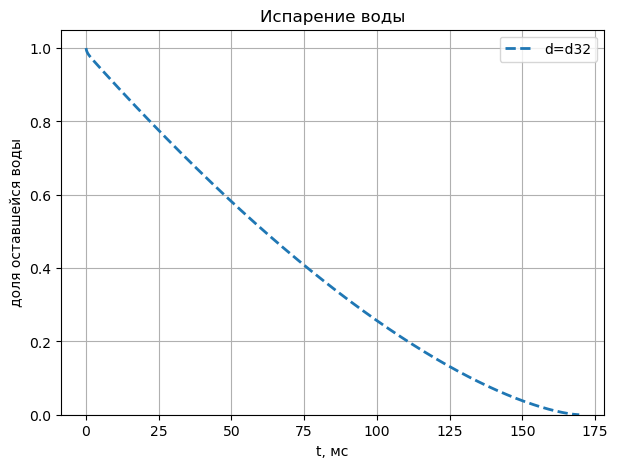

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

plt.plot(t_ms_sing, frac_left_from_air_sing, '--', lw=2, label='d=d32')

plt.xlabel('t, мс')
plt.ylabel('доля оставшейся воды')
plt.title('Испарение воды')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

Капли все испарятся за тот же промежуток времени (примерно), и повышение влажности удлинило путь только на 43 мм. Интересно, что капля охлаждается ниже температуры потока, до температуры влажного термометра. И для случая когда влажность меняется ее температура повышается.

### 2. Капли как распределение Розина-Рамблера

Теперь стоит разбить на группы по распределению Розина-Рамблера и испарять......... пускай будет 40 групп и так как влажность воздуха одан для свях и меняется во времени в зависимости от кол-во испаренной жидкости состема ОДУ будет совместной для всех группы и размера 40X4 =160 уравнений 

In [61]:
# Для распределения капель воды по диаметрам
d_exp = np.linspace(dmin_exp, dmax_exp, 10000)
dist_exp = getRRdist(d_exp, Xexp, qtab)
dist_dens_exp = np.gradient(dist_exp, d_exp)

In [62]:
# количество групп разбиения
N_bins = 40
# границы групп
edges = np.linspace(dmin_exp, dmax_exp, N_bins + 1)
# середины групп
D_bins = 0.5 * (edges[:-1] + edges[1:])
# массовая доля воды в группе
F_edges = getRRdist(edges, Xexp, qtab)                           # границы областей
mass_frac = np.diff(F_edges)                                     # доли массы 
# Начальная масса одной капли в каждой группе
m_drop0_bins = rho_w * np.pi / 6 * D_bins**3
# Число капель в секунду в каждом бине
Ndrop_dot_bins = Gtube * mass_frac / m_drop0_bins
print("удельная суммарная масса капель =", np.sum(mass_frac))    # потеряли 2% слева и справа, потому что dmin и dmax такие выбрали по 1% они отсекают

удельная суммарная масса капель = 0.98


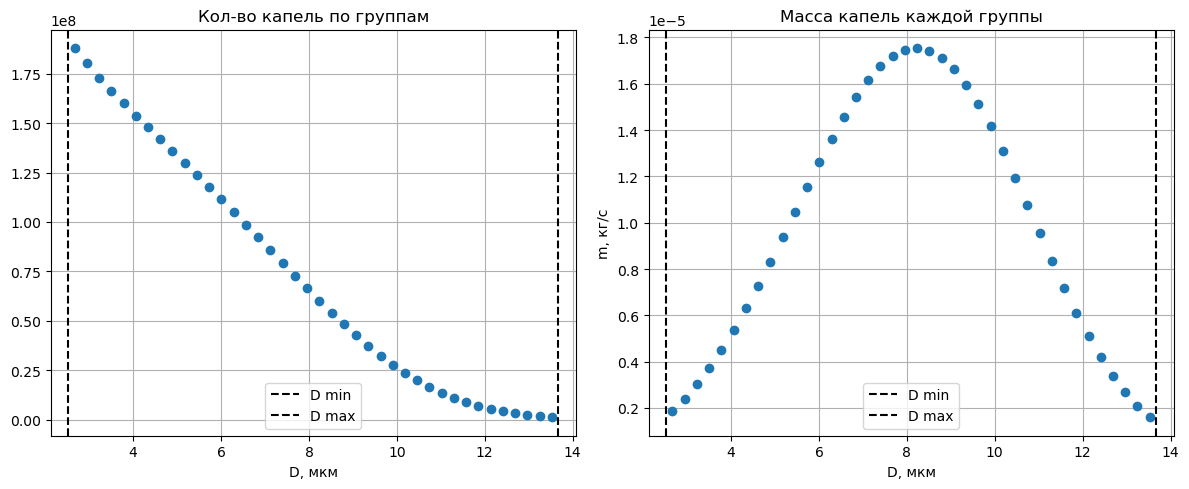

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 1. Диаметр капли
ax[0].plot(D_bins*1e6, Ndrop_dot_bins, 'o', lw=0.75)
ax[0].axvline(dmin_exp*1e6, linestyle="--", color='black', label='D min')
ax[0].axvline(dmax_exp*1e6, linestyle="--", color='black', label='D max')
ax[0].set_xlabel('n')
ax[0].set_xlabel('D, мкм')
ax[0].set_title('Кол-во капель по группам')
ax[0].legend()
ax[0].grid(True)
# 2. Скорость капли
ax[1].plot(D_bins*1e6, Gtube * mass_frac, 'o', lw=0.75)
ax[1].axvline(dmin_exp*1e6, linestyle="--", color='black', label='D min')
ax[1].axvline(dmax_exp*1e6, linestyle="--", color='black', label='D max')
ax[1].set_xlabel('D, мкм')
ax[1].set_ylabel('m, кг/с')
ax[1].set_title('Масса капель каждой группы')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Теперь осталось переформатировать правую часть систему уравнений, они должны решать одновременно для каждой из групп капель

In [64]:
def bins_rhs_humidity(t, y):
    """
    y = [Dt_1...Dt_N, Ut_1...Ut_N, Tt_1...Tt_N, Wt]
    """
    N = N_bins
    Dt = y[0:N_bins]
    Ut = y[N_bins:2*N_bins]
    Tt = y[2*N_bins:3*N_bins]
    Wt = y[-1]                                 # одна на всех

    dD_dt = np.zeros(N_bins)
    dU_dt = np.zeros(N_bins)
    dT_dt = np.zeros(N_bins)

    # текущая относительная влажность
    rh_t =  W2RH(Wt, Tg, P0) 

    # пробежимся по всем группам, как мы делали выше
    
    evap_total = 0.0  # кг/с, суммарное испарение всех капель, нужно будет суммировать по группам
    
    for i in range(N_bins):
        # если бин уже испарился, дальше его не считаем
        if Dt[i] <= D_min_stop:
            dD_dt[i] = 0.0
            dU_dt[i] = 0.0
            dT_dt[i] = 0.0
            continue
        # 1. Движение капли
        dU_dt[i] = dudt(Dt[i], Ut[i])
        # 2. Изменение диаметра
        dD_dt[i], m2evap = dmdt(Dt[i], rh_t, Ut[i], Tt[i])
        # 3. Теплообмен
        dT_dt[i] = dTdt(Dt[i], m2evap, Ut[i], Tt[i])
        evap_total +=Ndrop_dot_bins[i] * m2evap                     # нужно ли запрещать конденсацию ? вопрос
    # 4. Рост влажности воздуха
    dW_dt = evap_total / G
    return np.concatenate([
        dD_dt,
        dU_dt,
        dT_dt,
        np.array([dW_dt])
    ])  

In [65]:
# Начальные условия
W0 = RH2W(rh0, Tg, P0)
D0_arr = D_bins.copy()
U0_arr = np.full(N_bins, Udrop0)
T0_arr = np.full(N_bins, T0)

# y = [D_i, U_i, T_i, x_i, W]
y0 = np.concatenate([
    D0_arr,
    U0_arr,
    T0_arr,
    np.array([W0])
])

In [66]:
def event_all_evaporated(t, y):
    D = y[0:N_bins]
    return np.max(D) - D_min_stop


event_all_evaporated.terminal = True
event_all_evaporated.direction = -1

In [67]:
sol = solve_ivp(
    bins_rhs_humidity,
    t_span=(0.0, tfin),
    y0=y0,
    method="RK45",
    events=event_all_evaporated,
    rtol=1e-7,
    atol=1e-10,
    max_step=1e-4,
)

In [68]:
N = N_bins

t = sol.t
D = sol.y[0:N, :]
U = sol.y[N:2*N, :]
T = sol.y[2*N:3*N, :]
x = cumulative_trapezoid(U, t, axis=1, initial=0.0)
W = sol.y[-1, :]

RH = np.array([
    W2RH(Wi, Tg, P0)
    for Wi in W
])
x_bins = cumulative_trapezoid(U, t, axis=1, initial=0.0)

print("success =", sol.success)
print("message =", sol.message)
print("t_final =", t[-1])
print("RH initial =", RH[0])
print("RH final =", RH[-1])
print("W final =", W[-1])

success = True
message = A termination event occurred.
t_final = 0.3589093041083635
RH initial = 0.0
RH final = 0.02570341295413779
W final = 7.959990337117146e-05


In [69]:
# Скорость испарения одна для каждой группы
# mdot_evap_bins[i, j] — скорость испарения одной капли i-го бина в момент t[j], кг/с
mdot_evap_bins = np.zeros_like(D)

for j in range(len(t)):
    RHt_bins = RH[j]                              # влажность газа одна общая для всех бинов
    active = D[:, j] > D_min_stop                 # какие бины еще не испарились
    D_now = np.maximum(D[:, j], D_min_stop)       # защита от D = 0

    _, mdot_now = dmdt(D_now, RHt_bins, U[:, j], T[:, j])
    mdot_evap_bins[:, j] = np.where(active, mdot_now, 0.0)

# --- 2. Суммарное испарение распределения ---
mdot_evap_total_bins = np.sum(Ndrop_dot_bins[:, None] * mdot_evap_bins, axis=0)


# Перевод единиц
t_ms = t * 1e3
D_um = D * 1e6
T_C = T - 273.15
mdot_evap_bins = mdot_evap_bins * 1e12  # кг/с -> нг/с

Отобразим результаты для сравнения

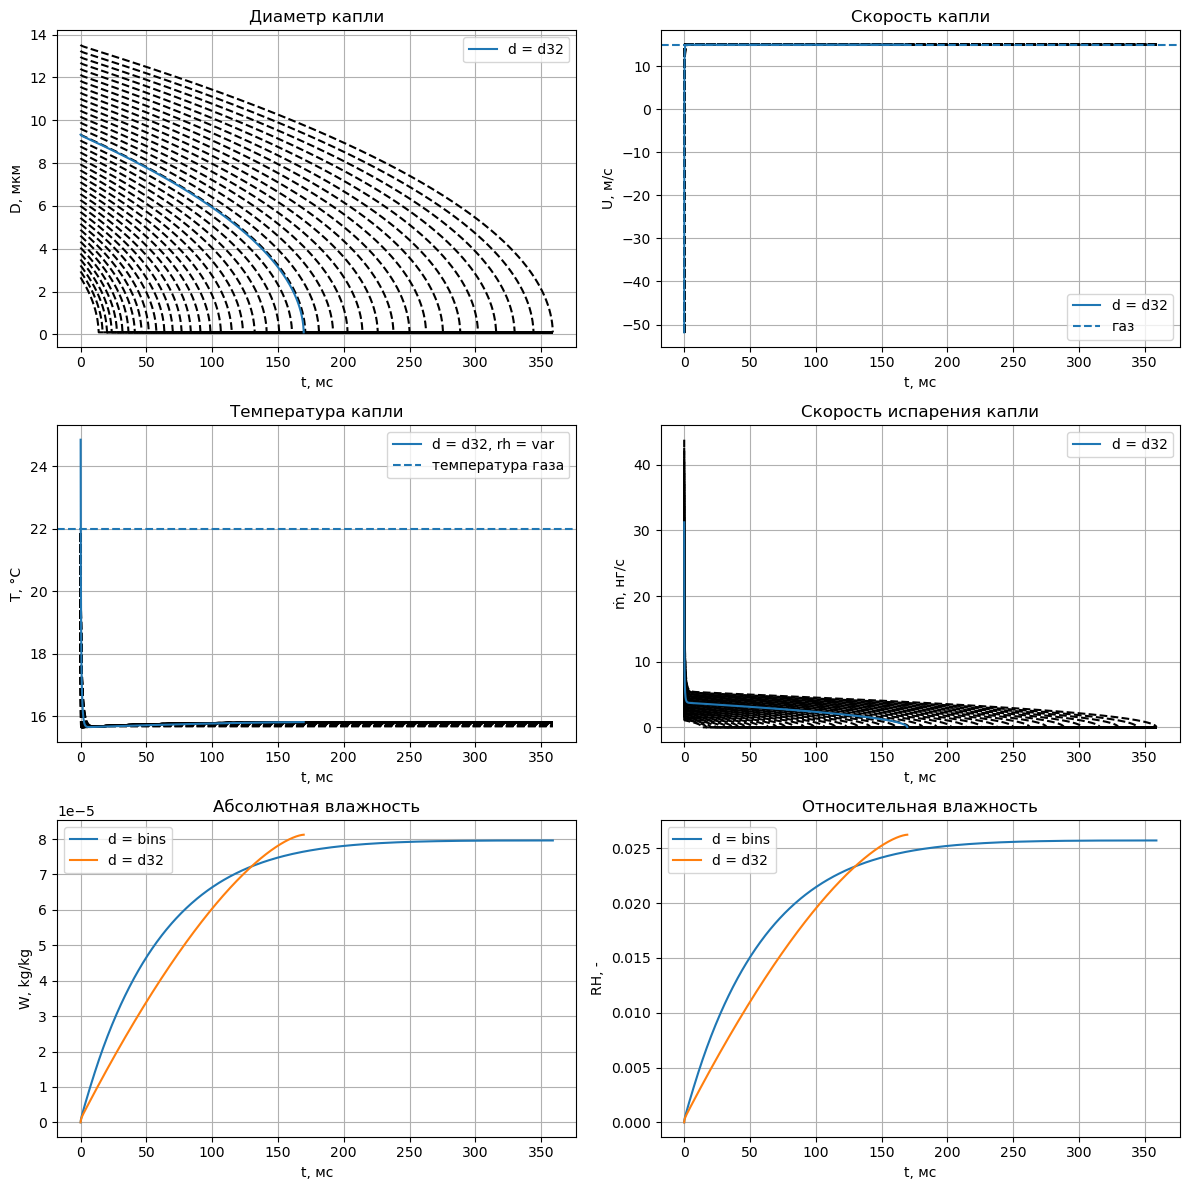

In [70]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

# 1. Диаметр капли


[ax[0, 0].plot(t_ms, D_um[i, :], linestyle='--',  color='black') for i in range(N_bins)]
ax[0, 0].plot(t_ms_sing, D_um_sing, label='d = d32')
ax[0, 0].set_xlabel('t, мс')
ax[0, 0].set_ylabel('D, мкм')
ax[0, 0].set_title('Диаметр капли')
ax[0, 0].legend()
ax[0, 0].grid(True)

# 2. Скорость капли
[ax[0, 1].plot(t_ms, U[i, :], linestyle='--',  color='black') for i in range(N_bins)]
ax[0, 1].plot(t_ms_sing, U_sing, label='d = d32')
ax[0, 1].axhline(Ug, linestyle='--', label='газ')
ax[0, 1].set_xlabel('t, мс')
ax[0, 1].set_ylabel('U, м/с')
ax[0, 1].set_title('Скорость капли')
ax[0, 1].legend()
ax[0, 1].grid(True)
#ax[0, 1].set_xlim([0, 10])
#ax[0, 1].set_ylim([14.9, 15.1])

# 3. Температура капли
[ax[1, 0].plot(t_ms, T_C[i, :], linestyle='--',  color='black') for i in range(N_bins)]
ax[1, 0].plot(t_ms_sing, T_C_sing, label='d = d32, rh = var')
ax[1, 0].axhline(Tg-273, linestyle='--', label='температура газа')
ax[1, 0].set_xlabel('t, мс')
ax[1, 0].set_ylabel('T, °C')
ax[1, 0].set_title('Температура капли')
ax[1, 0].grid(True)
ax[1, 0].legend()

# 4. Скорость испарения
[ax[1, 1].plot(t_ms, mdot_evap_bins[i, :], linestyle='--',  color='black') for i in range(N_bins)]
ax[1, 1].plot(t_ms_sing, mdot_ng_s_sing, label='d = d32')
ax[1, 1].set_xlabel('t, мс')
ax[1, 1].set_ylabel('ṁ, нг/с')
ax[1, 1].set_title('Скорость испарения капли')
ax[1, 1].grid(True)
ax[1, 1].legend()



# 5. Влажность W
ax[2, 0].plot(t_ms, W, label='d = bins')
ax[2, 0].plot(t_ms_sing, W_sing, label='d = d32')
ax[2, 0].set_xlabel('t, мс')
ax[2, 0].set_ylabel('W, kg/kg')
ax[2, 0].set_title('Абсолютная влажность')
ax[2, 0].grid(True)
ax[2, 0].legend()


# 6. Влажность RH относительная
ax[2, 1].plot(t_ms, RH, label='d = bins')
ax[2, 1].plot(t_ms_sing, RH_sing, label='d = d32')
ax[2, 1].set_xlabel('t, мс')
ax[2, 1].set_ylabel('RH, -')
ax[2, 1].set_title('Относительная влажность')
ax[2, 1].grid(True)
ax[2, 1].legend()


plt.legend()
plt.tight_layout()
plt.show()

Доля воды испарившейся от времени

In [78]:
# Сколько воды перешло в пар, кг/с
water_evap_from_air = G * (W - W0)
# Доля испарившейся воды через баланс влажности
frac_evap_from_air = water_evap_from_air / Gtube
# Доля оставшейся воды
frac_left_from_air = 1 - frac_evap_from_air
print(f"Оставшаяся вода: {frac_left_from_air[-1]:.5f}") 

Оставшаяся вода: 0.02000


Осталось 2% потому что я отсек по 1% с каждой стороны распределения............. надо подумать, что делать

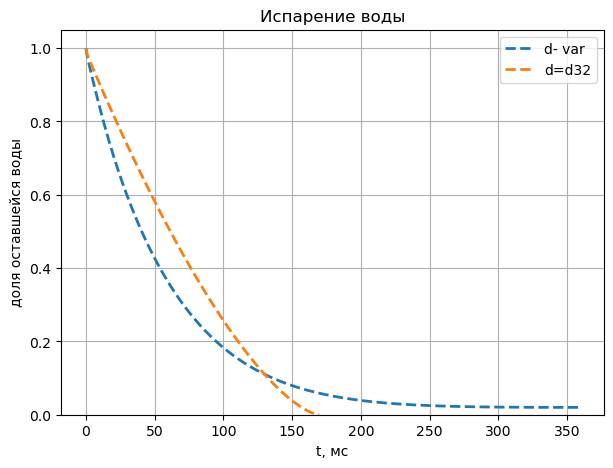

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

plt.plot(t_ms, frac_left_from_air, '--', lw=2, label='d- var')
plt.plot(t_ms_sing, frac_left_from_air_sing, '--', lw=2, label='d=d32')

plt.xlabel('t, мс')
plt.ylabel('доля оставшейся воды')
plt.title('Испарение воды')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [112]:
print(f"Общее пройденное каплями расстояние до испарения при D-var: {x[1,-1]:.5f} м" ) 
print(f"Общее пройденное каплями расстояние до испарения при D=D32: {x_sing[-1]:.5f} м" ) 

Общее пройденное каплями расстояние до испарения при D-var: 5.38287 м
Общее пройденное каплями расстояние до испарения при D=D32: 2.53850 м


Получилось расстояние в два раза длиннее, чтобы испарились и большие капли